## MARBL diagnostics, compare timeseries of global metrics between multiple cases (only 2-d variables)


In [1]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import os
from glob import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cftime
import pandas as pd
import matplotlib.gridspec as gridspec
from xgcm import Grid
xr.set_options(keep_attrs=True);

### Cases to be compared with major changes

#### All cases are with alpha09d tag


### Come up with short names for each segment

In [2]:
short_names = ['374',
               '377_part1',
               '377_part2',
               '392',
               '380_part1',
               '380_part2'
              ]

### Define number of years and number of cases

In [3]:
num_cases = len(short_names)
#num_years = 151 #max years in any of the runs

### Define cases

In [4]:
sandboxes = ['b.e30_alpha09d_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3', #374
             'b.e30_alpha09d_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3', #377 part 1
             'b.e30_alpha09d_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3', #377 part 2
             'b.e30_alpha09e_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3', #392
             'b.e30_alpha09d_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3', #380 part 1
             'b.e30_alpha09d_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3', #380 part 2
            ]

            

case_nums = ['374','377','377','392','380','380']
t_freqs   = ['mon','ann','mon','mon','ann','mon']
users     = ['hannay','hannay','hannay','hannay','hannay','hannay']
run_st_year  = [1,   1,   104, 1,  1,  43]
run_end_year = [136, 103, 169, 40, 42, 138]

yr_offset = [0, 136, 136, 248, 136, 136] #this is the offset from the first run relative to the run year

### Define the year range

start_yr = 1
endyr = start_yr + num_years 

### 2-D variable list

In [5]:
variables2d = ['photoC_TOT_zint','photoC_sp_zint','photoC_diat_zint',
               'photoC_diaz_zint','photoC_cocco_zint','CaCO3_PROD_zint',
               'POC_FLUX_100m','x_graze_microzoo_zint',
               'x_graze_mesozoo_zint','IFRAC','FG_CO2','diat_Fe_lim_surf'] 

coords = {'x':'yh','y':'xh'}


keepthese=['z_l','z_i','time_bounds','time','average_T1', 'average_T2','average_DT'] + variables2d + list(coords.values())

### Get dask going

In [6]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=2,
        memory='25 GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=25GB',
        project='NCGD0011',
        walltime='03:00:00',
        interface='ext',
        log_directory='./dask-logs'
    )

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [7]:
cluster, client = get_ClusterClient()
cluster.scale(12) 
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.195:37633,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


### Read in all the data

In [8]:
cases_dict = {}
i = 0
for case_num in case_nums:
    
    start_yr = run_st_year[i]
    endyr = run_end_year[i]
    case = sandboxes[i] + '.' + case_num
    print(case)
    files = []

    if t_freqs[i] == 'ann':
        
        for year in range(run_st_year[i],run_end_year[i]+1):

            if year == run_st_year[i]:
                print('starting on run:',case_num, '; getting years ', run_st_year[i], ' to ', run_end_year[i])
                print('(annual data)')
            
            yr4="{:04d}".format(year)
            #print('doing simulation year', year, '!')
            
            files.extend(sorted(glob(f'/glade/derecho/scratch/{users[i]}/archive/{case}/ocn/hist/{case}.mom6.h.bgc.native_annual.{yr4}.nc')))
        ds_tmp = xr.open_mfdataset(files,decode_times=True,decode_coords=False, concat_dim='time',combine='nested' )
        ### drop unnecessary variables
        ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keepthese])
        cases_dict[short_names[i]] = ds_tmp #no need to do annual interpolation

        i = i + 1

    else: #monthly!
    
        for year in range(run_st_year[i],run_end_year[i]+1):

            if year == run_st_year[i]:
                print('starting on run:',case_num, '; getting years ', run_st_year[i], ' to ', run_end_year[i])
                print('(monthly data)')
                
            yr4="{:04d}".format(year)
            
            for month in range(1, 13):
                mo2="{:02d}".format(month)
                files.extend(sorted(glob(f'/glade/derecho/scratch/{users[i]}/archive/{case}/ocn/hist/{case}.mom6.h.bgc.native.{yr4}-{mo2}.nc')))
                
        ds_tmp = xr.open_mfdataset(files,decode_times=True,decode_coords=False, concat_dim='time',combine='nested' )
            
        ### drop unnecessary variables
        ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keepthese])
        ### resample to annual means
        cases_dict[short_names[i]] = ds_tmp.resample({'time':'A'}).mean(dim='time', keep_attrs=True).compute()

        i = i + 1

b.e30_alpha09d_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3.374
starting on run: 374 ; getting years  1  to  136
(monthly data)
b.e30_alpha09d_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3.377
starting on run: 377 ; getting years  1  to  103
(annual data)
b.e30_alpha09d_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3.377
starting on run: 377 ; getting years  104  to  169
(monthly data)
b.e30_alpha09e_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3.392
starting on run: 392 ; getting years  1  to  40
(monthly data)
b.e30_alpha09d_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3.380
starting on run: 380 ; getting years  1  to  42
(annual data)
b.e30_alpha09d_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3.380
starting on run: 380 ; getting years  43  to  138
(monthly data)


In [9]:
cases_dict.keys()

dict_keys(['374', '377_part1', '377_part2', '392', '380_part1', '380_part2'])

### now fix the time dimension so the year are sequential

In [10]:
i = 0

for case_num in short_names:
    cases_dict[case_num]['time'] = np.arange(run_st_year[i] + yr_offset[i], run_end_year[i] + yr_offset[i] + 1, 1)
    i = i + 1

In [11]:
for case_num in short_names:
    print(cases_dict[case_num].time.values)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136]
[137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154
 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172
 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190
 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208
 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226
 227 228 229 230 231 232 233 234 235 236 237 238 239]
[240 241 242 243 244 245 246

## Get the grid data for MOM6

In [12]:
ds_grid = xr.open_dataset(f'/glade/work/kristenk/cesm_work/mom6_static_files/g.e23b16.TL319_t232.GIAFMARBL.001.mom6.h.static.nc')

In [13]:
lons = ds_grid.geolon
lats = ds_grid.geolat
area = ds_grid.areacello #m2

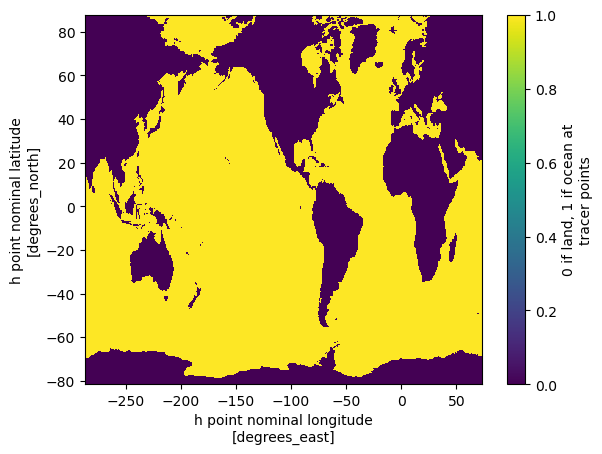

In [14]:
ds_grid.wet.plot()

### Compute global BGC metrics 

In [15]:
mmols_to_PgCyr = 1e-3 * 12. * 1e-15 * 365. * 86400.

variables = [f'photoC_{phyto}_zint' for phyto in ['diat', 'sp', 'diaz', 'cocco', 'TOT']]
variables = variables + ['CaCO3_PROD_zint','POC_FLUX_100m','FG_CO2']
variables = variables + [f'x_graze_{zoo}_zint' for zoo in ['microzoo', 'mesozoo']]


glb_ds_dict = {}
i = 0
for case_num in short_names:
    
    case = sandboxes[i] + '.' + case_num

    ds_glb = xr.Dataset()

    ds = cases_dict[case_num]
    
    for v in variables:
        ds_glb[v] = ((ds[v] * area).sum(dim=('xh', 'yh'))).compute() #mmol/m
        ds_glb[v].attrs = ds[v].attrs
    
        ds_glb[v] = ds_glb[v] * mmols_to_PgCyr        
        ds_glb[v].attrs['units'] = 'Pg C yr$^{-1}$'
    
    
    ######### diatom and zooplankton percents of total NPP
    ds_glb['diatNPPpercent'] = ds_glb.photoC_diat_zint / ds_glb.photoC_TOT_zint * 100.
    ds_glb['diatNPPpercent'].attrs['units'] = '%'
    
    ds_glb['zooprodNPPpercent'] = (ds_glb['x_graze_mesozoo_zint'] + ds_glb['x_graze_microzoo_zint'])/ds_glb['photoC_TOT_zint'] * 100.
    ds_glb['zooprodNPPpercent'].attrs['units'] = '%'
    
    ds_glb = ds_glb.compute()

    glb_ds_dict[case_num] = ds_glb
    i = i + 1

In [16]:
glb_ds_dict.keys()

dict_keys(['374', '377_part1', '377_part2', '392', '380_part1', '380_part2'])

### Make some timeseries plots for global BGC metrics

In [17]:
years = np.arange(1,len(ds_glb.time)+1,1)

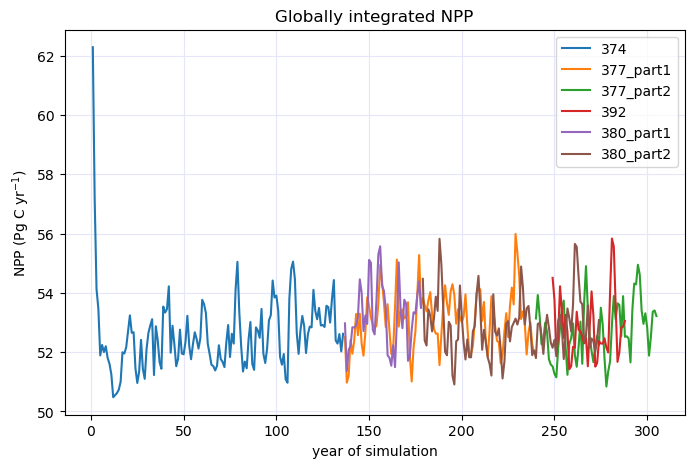

In [18]:
fig = plt.figure(figsize=(8,5))

ax = fig.add_subplot(1,1,1)
ax.set_title('Globally integrated NPP')

i = 0

for case_num in short_names:
    ax.plot(glb_ds_dict[case_num]['time'],glb_ds_dict[case_num]['photoC_TOT_zint'],label=short_names[i])
    i = i + 1


ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()
ax.set(ylabel='NPP (Pg C yr$^{-1}$)',xlabel='year of simulation');

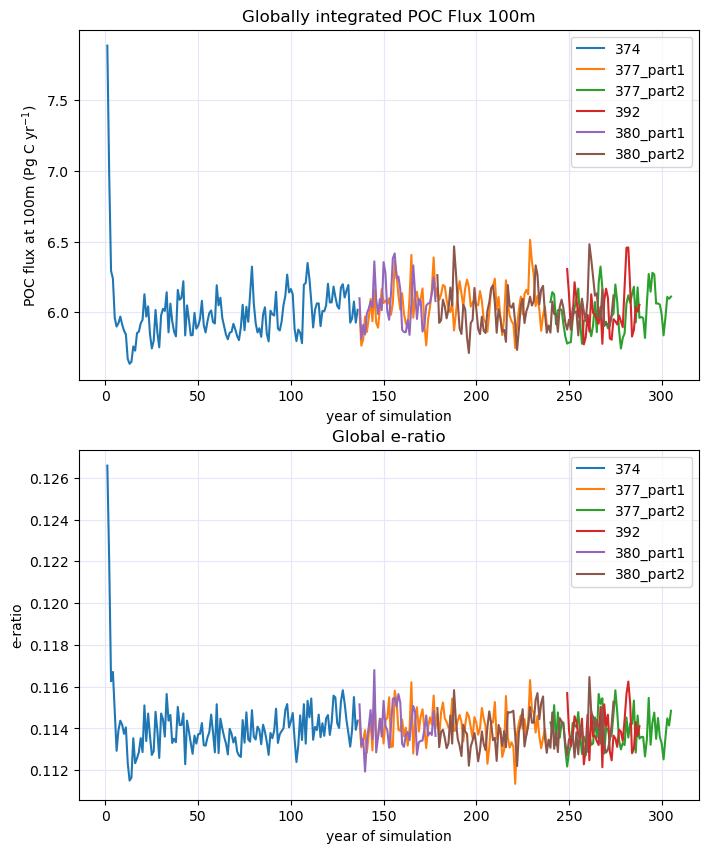

In [19]:
fig = plt.figure(figsize=(8,10))

####################
ax = fig.add_subplot(2,1,1)
ax.set_title('Globally integrated POC Flux 100m')

i = 0

for case_num in short_names:
    ax.plot(glb_ds_dict[case_num]['time'],glb_ds_dict[case_num]['POC_FLUX_100m'],label=short_names[i])
    i = i + 1

ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()
ax.set(ylabel='POC flux at 100m (Pg C yr$^{-1}$)',xlabel='year of simulation');

######################
ax = fig.add_subplot(2,1,2)
ax.set_title('Global e-ratio')

i = 0

for case_num in short_names:
    ax.plot(glb_ds_dict[case_num]['time'],glb_ds_dict[case_num]['POC_FLUX_100m']/glb_ds_dict[case_num]['photoC_TOT_zint'],label=short_names[i])
    i = i + 1

ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()
ax.set(ylabel='e-ratio',xlabel='year of simulation');

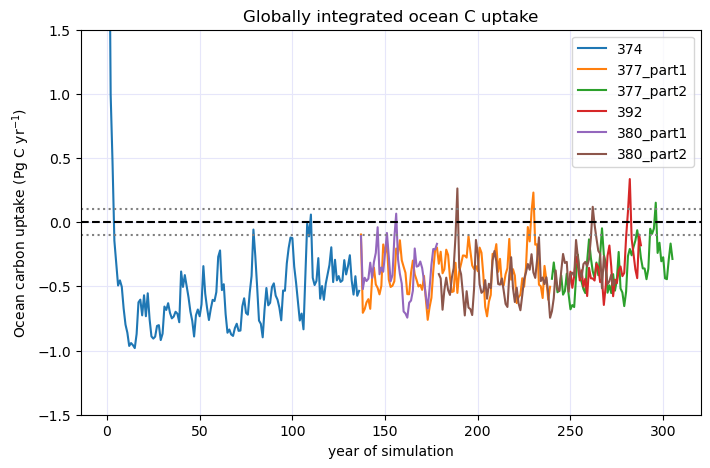

In [20]:
fig = plt.figure(figsize=(8,5))

####################
ax = fig.add_subplot(1,1,1)
ax.set_title('Globally integrated ocean C uptake')

i = 0

for case_num in short_names:
    ax.plot(glb_ds_dict[case_num]['time'],glb_ds_dict[case_num]['FG_CO2'],label=short_names[i])
    i = i + 1

ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');
ax.axhline(0,linestyle='--', color='black')
ax.axhline(0.1,linestyle=':', color='gray')
ax.axhline(-0.1,linestyle=':', color='gray')
ax.legend()
ax.set_ylim(-1.5,1.5)
ax.set(ylabel='Ocean carbon uptake (Pg C yr$^{-1}$)',xlabel='year of simulation');


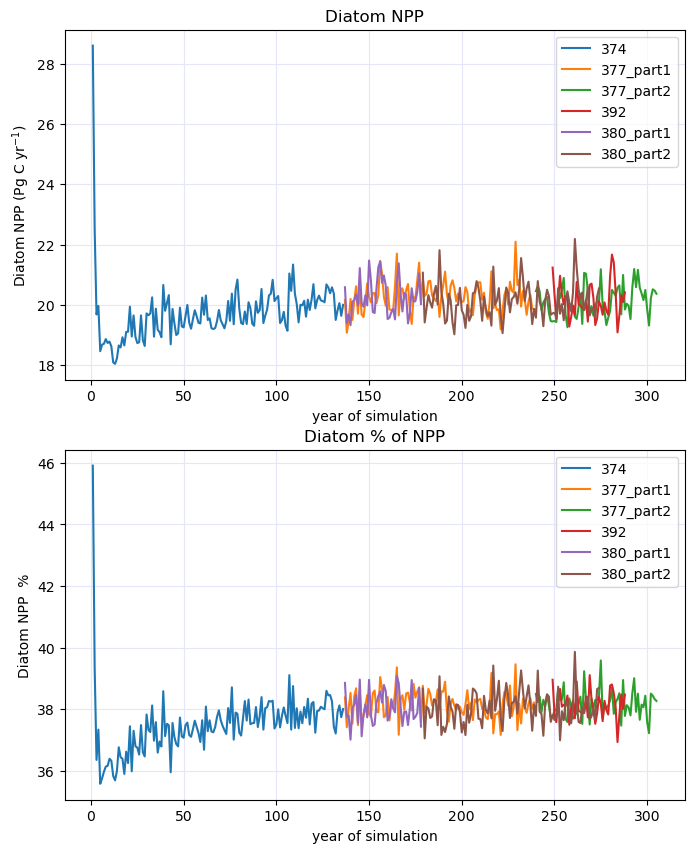

In [21]:
fig = plt.figure(figsize=(8,10))

#################
ax = fig.add_subplot(2,1,1)
ax.set_title('Diatom NPP')

i = 0

for case_num in short_names:
    ax.plot(glb_ds_dict[case_num]['time'],glb_ds_dict[case_num]['photoC_diat_zint'],label=short_names[i])
    i = i + 1

ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()

ax.set(ylabel='Diatom NPP (Pg C yr$^{-1}$)',xlabel='year of simulation');

##################
ax = fig.add_subplot(2,1,2)
ax.set_title('Diatom % of NPP')

i = 0

for case_num in short_names:
    ax.plot(glb_ds_dict[case_num]['time'],glb_ds_dict[case_num]['diatNPPpercent'],label=short_names[i])
    i = i + 1

ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()

ax.set(ylabel='Diatom NPP  %',xlabel='year of simulation');